In [1]:
import os
import json
import torch
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

from torcheval.metrics.functional import perplexity

# set default type to float16
# torch.set_default_dtype(torch.float16)
# set seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


#### Monkey-patch

In [2]:
from monkey_patch_utils import collect_saved_tensors, get_model_sizes
# pretrained_model_name_or_path = 'meta-llama/Llama-2-7b-hf'
# pretrained_model_name_or_path = 'meta-llama/Llama-3.1-8B'
pretrained_model_name_or_path = 'meta-llama/Llama-3.2-3B'
# pretrained_model_name_or_path = 'Qwen/Qwen2.5-7B'
# pretrained_model_name_or_path = 'allenai/OLMo-2-1124-7B'
# No patching!
model = AutoModelForCausalLM.from_pretrained(pretrained_model_name_or_path).to(device)
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

#### Data

In [3]:
from datasets import load_dataset

ds = load_dataset('hails/mmlu_no_train', name='high_school_computer_science')['dev'] # choose from test (100), validation (9), dev (5)
# ds = load_dataset('hails/mmlu_no_train', name='high_school_european_history')['test']

def doc_to_text_mmlu(doc):
    subject = ' '.join(doc['subject'].split('_'))
    description = f"The following are multiple choice questions (with answers) about {subject}.\n\n"
    answer_idx = doc['answer']
    choice = ["A", "B", "C", "D"][answer_idx]
    return f"{description}{doc['question']}\nA. {doc['choices'][0]}\nB. {doc['choices'][1]}\nC. {doc['choices'][2]}\nD. {doc['choices'][3]}\nAnswer: {choice}"

passage = doc_to_text_mmlu(ds[2])
print(passage)

The following are multiple choice questions (with answers) about high school computer science.

What is the output of "abc"[::-1] in Python 3?
A. Error
B. abc
C. cba
D. c
Answer: C


In [5]:
with torch.no_grad():
    inputs = tokenizer(passage, return_tensors="pt") # , add_special_tokens=False
    # to device
    inputs = {k: v.to(device) for k, v in inputs.items()}
    # Get outputs with keys ['logits', 'hidden_states', 'attentions']
    outputs = model(**inputs, output_attentions=True, output_hidden_states=False, use_cache=False)

# saved_tensors = collect_saved_tensors(model)

if outputs.attentions: print(f"Attention len {len(outputs.attentions)} shape: {outputs.attentions[0].shape}")
if outputs.hidden_states: print(f"Hidden states len {len(outputs.hidden_states)} shape: {outputs.hidden_states[0].shape}")
# if saved_tensors.value_states: print(f"Value states len {len(saved_tensors.value_states)} shape: {saved_tensors.value_states[0].shape}")
# if saved_tensors.pre_output_proj_hidden_states: print(f"Pre output proj len {len(saved_tensors.pre_output_proj_hidden_states)} shape: {saved_tensors.pre_output_proj_hidden_states[0].shape}")
# if saved_tensors.post_output_proj_hidden_states: print(f"Post output proj len {len(saved_tensors.post_output_proj_hidden_states)} shape: {saved_tensors.post_output_proj_hidden_states[0].shape}")

Attention len 28 shape: torch.Size([1, 24, 53, 53])


In [6]:
num_layers, num_attention_heads, num_key_value_heads, head_dim, hidden_size = get_model_sizes(model)
print(f"{num_layers=}\n{num_attention_heads=}\n{num_key_value_heads=}\n{head_dim=}\n{hidden_size=}")

num_layers=28
num_attention_heads=24
num_key_value_heads=8
head_dim=128
hidden_size=3072


Number of components to explain 95% of the variance: 82


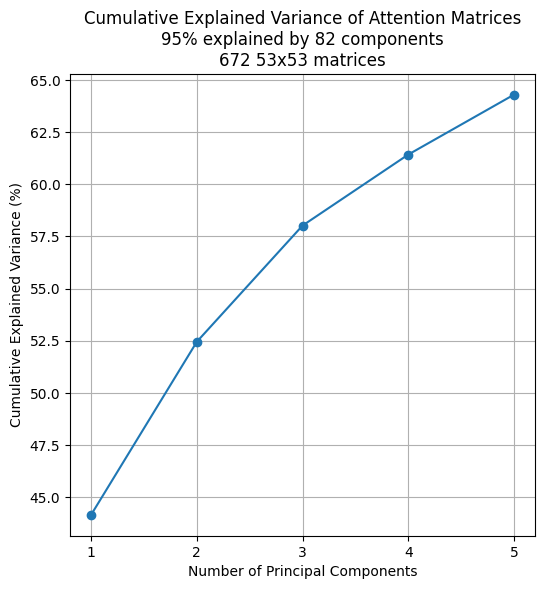

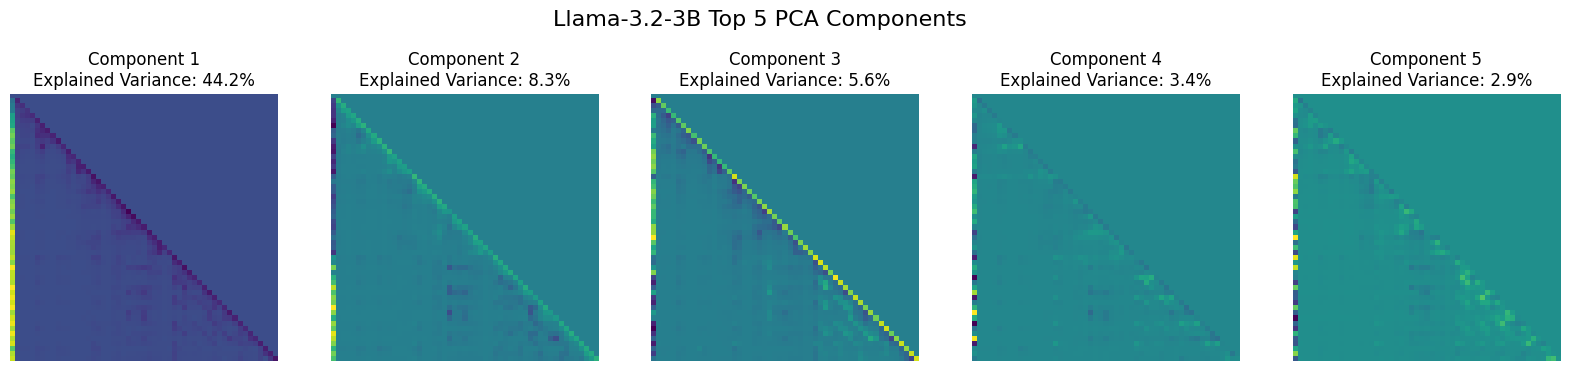

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca_variance(attentions, top_k=5):
    """
    Compute and plot the cumulative explained variance from PCA on attention matrices.
    
    Parameters:
    - attentions: numpy array of shape (num_layers, num_attention_heads, S, S)
    - top_k: number of components to plot
    """
    num_layers, num_attention_heads, S, _ = attentions.shape
    total_heads = num_layers * num_attention_heads

    # Apply PCA
    # Flatten each S x S matrix into a vector of length S*S
    flattened_attentions = attentions.reshape(total_heads, S*S)
    pca = PCA()
    pca.fit(flattened_attentions)

    # Compute cumulative explained variance
    explained_variance_ratio = pca.explained_variance_ratio_ * 100 # convert to percentage
    cumulative_variance = np.cumsum(explained_variance_ratio)

    # Find the number of components needed to explain 95% of the variance
    num_components_95 = np.argmax(cumulative_variance >= 95) + 1
    print(f"Number of components to explain 95% of the variance: {num_components_95}")

    # Plot the cumulative explained variance
    plot_up_to_component = 5
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(cumulative_variance[:plot_up_to_component], linestyle='-', color='tab:blue', marker='o')
    ax.set_xlabel('Number of Principal Components')
    ax.set_ylabel('Cumulative Explained Variance (%)')
    ax.set_title(f'Cumulative Explained Variance of Attention Matrices\n95% explained by {num_components_95} components\n{total_heads} {S}x{S} matrices')
    # x ticks only at integer locations and start at 0 but labeled as 1
    ax.set_xticks(np.arange(0, plot_up_to_component))
    ax.set_xticklabels(np.arange(1, plot_up_to_component+1))
    ax.grid(True)

    # Plot the top k components
    fig, ax = plt.subplots(1, top_k, figsize=(20, 4.5))
    fig.suptitle(f'{pretrained_model_name_or_path.split("/")[-1]} Top {top_k} PCA Components', fontsize=16)
    # Get abs max value for color normalization
    # max_val = np.max(np.abs(pca.components_[:top_k]))
    for i in range(top_k):
        ax[i].imshow(pca.components_[i].reshape(S, S), cmap='viridis')
        ax[i].set_title(f"Component {i+1}\nExplained Variance: {explained_variance_ratio[i]:.1f}%")
        ax[i].axis('off')

# Run the function
attentions = torch.concat(outputs.attentions, dim=0).cpu().numpy()
# Ensure no values are nan
assert not np.isnan(attentions).any(), "Some attention values are NaN"
plot_pca_variance(attentions)